# Phase 4 guide — six-container federated-learning demonstration

This notebook explains the completed Docker Compose demo from checked-in
configuration and measured results. It does not replace the control-center or
client processes, and it runs successfully even when Docker is stopped. Live
operation remains in `phase4/app/`, `phase4/docker-compose.yml`, and
`phase4/scripts/`.

## 1. Configuration and saved evidence

The guide uses stable benchmark and event excerpts generated from the definitive
run. Raw runtime logs remain disposable operational evidence.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

HERE = Path.cwd().resolve()
if (HERE / "phase4" / "docker-compose.yml").is_file():
    PROJECT_ROOT = HERE
elif HERE.name == "notebooks" and (HERE.parent / "phase4" / "docker-compose.yml").is_file():
    PROJECT_ROOT = HERE.parent
else:
    raise RuntimeError(f"Run from the uavids_federated root or notebooks directory, not {HERE}")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

from phase4.app.common import build_contract, decode_state, encode_state, sha256_path, state_spec
from uavids_fl import BinaryMLP

demo = json.loads((PROJECT_ROOT / "phase4" / "config" / "demo_config.json").read_text(encoding="utf-8"))
lock = json.loads((PROJECT_ROOT / "config" / "phase3_locked_config.json").read_text(encoding="utf-8"))
benchmark = json.loads((PROJECT_ROOT / "phase4" / "results" / "benchmark_summary.json").read_text(encoding="utf-8"))
events = json.loads((PROJECT_ROOT / "phase4" / "results" / "event_excerpt.json").read_text(encoding="utf-8"))
timings = pd.read_csv(PROJECT_ROOT / "phase4" / "results" / "client_round_timings.csv")

assert demo["mode"] == "demo_nonresearch"
assert benchmark["state"] == "completed"
print(f"Configuration: {demo['config_version']}; protocol: {demo['protocol_version']}")
print(f"Definitive run: {benchmark['run_id']}; state: {benchmark['state']}")
print("Docker does not need to be running to execute this guide.")

Configuration: uavids-phase4-demo-v1; protocol: phase4-http-fedavg-v1
Definitive run: 9ec38846-0983-4f1e-a343-f7f8a320ba46; state: completed
Docker does not need to be running to execute this guide.


## 2. Six-container architecture

```text
five isolated client containers             control-center container
one read-only train.csv each                 validation.csv only
        |                                            |
        +-- register and verify contract ---------->|
        |<----------- global model -----------------+
        +-- real local CPU training                 |
        +-- validated model update ---------------->|
                                                     +-- sample-weighted FedAvg
                                                     +-- metrics and GUI events
```

All communication is ordinary HTTP on one Compose bridge network. The server
never reads a client training CSV; clients never share their CSVs with one
another.

In [2]:
service_table = pd.DataFrame([
    {"service": "control-center", "role": "coordinate, aggregate, validate", "data": "validation.csv", **demo["server"]},
    *[
        {
            "service": item["client_id"],
            "role": "local training",
            "data": item["partition_filename"],
            "cpus": item["cpus"],
            "memory": item["memory"],
        }
        for item in demo["clients"]
    ],
])
display(service_table)

,service,role,data,cpus,memory
0,control-center,"coordinate, aggregate, validate",validation.csv,1.25,768m
1,uav-client-1,local training,train_uav_client_1.csv,0.65,512m
2,uav-client-2,local training,train_uav_client_2.csv,0.55,512m
3,uav-client-3,local training,train_uav_client_3.csv,0.35,448m
4,uav-client-4,local training,train_uav_client_4.csv,1.00,768m
5,uav-client-5,local training,train_uav_client_5.csv,0.45,512m


## 3. Device-inspired profiles

The names provide an understandable range of edge classes. Docker limits are
process allocations, not the products' full specifications or hardware
emulation. Product sources and the exact mapping rationale are recorded in
[`phase4/DEVICE_PROFILES.md`](../phase4/DEVICE_PROFILES.md).

,client,logical_rows,profile,CPU limit,memory limit MiB,measured peak MiB,measured peak CPU %
0,uav-client-1,1230,Raspberry Pi 4 Model B-inspired,0.6,512,270.1,65.1
1,uav-client-2,1046,NVIDIA Jetson Nano-inspired,0.6,512,270.7,54.6
2,uav-client-3,591,Raspberry Pi Zero 2 W-inspired,0.4,448,269.2,36.1
3,uav-client-4,2027,NVIDIA Jetson Orin Nano 8GB-inspired,1.0,768,272.4,99.0
4,uav-client-5,1254,NXP NavQPlus-inspired,0.4,512,270.4,45.5


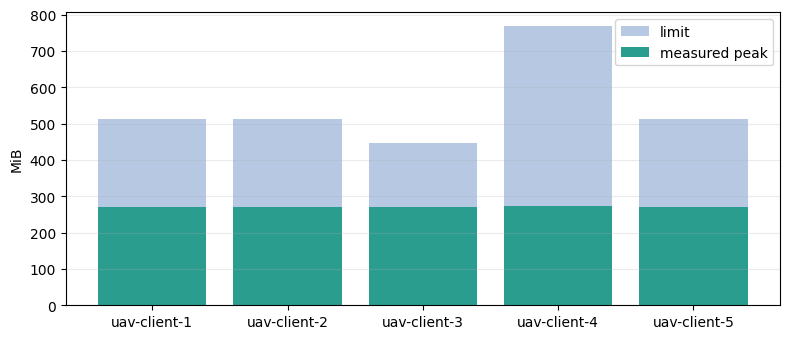

In [3]:
profile_rows = []
for item in demo["clients"]:
    measured = benchmark["resource_samples"][item["client_id"]]
    profile_rows.append({
        "client": item["client_id"],
        "logical_rows": item["samples"],
        "profile": item["profile"],
        "CPU limit": item["cpus"],
        "memory limit MiB": int(item["memory"].removesuffix("m")),
        "measured peak MiB": measured["peak_memory_mib"],
        "measured peak CPU %": measured["peak_cpu_percent_of_one_host_core"],
    })
profiles = pd.DataFrame(profile_rows)
display(profiles.round(1))

fig, axis = plt.subplots(figsize=(8, 3.5))
axis.bar(profiles["client"], profiles["memory limit MiB"], label="limit", color="#b7c9e2")
axis.bar(profiles["client"], profiles["measured peak MiB"], label="measured peak", color="#2a9d8f")
axis.set_ylabel("MiB")
axis.legend()
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The five inspirations are Raspberry Pi 4, Jetson Nano, Raspberry Pi Zero 2 W,
Jetson Orin Nano, and NXP NavQPlus. The definitive run needed no increase from
the initial limits. The x86 containers cannot support claims about ARM timing,
GPU/NPU acceleration, power, thermal behavior, radio links, or flight hardware.

## 4. Compatibility contract

Every service independently derives the same contract from the frozen Phase 3
lock and the Phase 4 demo configuration.

In [4]:
contract = build_contract(lock, demo)
contract_view = pd.DataFrame([
    ("contract hash", contract["contract_hash"]),
    ("Phase 3 design", contract["phase3_design_version"]),
    ("features", len(contract["feature_order"])),
    ("architecture", f"{contract['input_dim']} -> {' -> '.join(map(str, contract['hidden_layers']))} -> 1"),
    ("local epochs", contract["local_epochs"]),
    ("aggregation", contract["aggregation"]),
    ("decision threshold", contract["decision_threshold"]),
], columns=["contract field", "value"])
display(contract_view)

assert sha256_path(PROJECT_ROOT / "config" / "phase3_locked_config.json") == demo["phase3_lock_sha256"]
assert sha256_path(PROJECT_ROOT / "artifacts_phase3" / "training_only_preprocessor.joblib") == lock["preprocessor"]["sha256"]
print("Frozen lock and preprocessor hashes verified.")

,contract field,value
0,contract hash,dd2281ef2a1ec98a9c2c6197067fe8029b76026e6f9710...
1,Phase 3 design,uavids-phase3-v1
2,features,15
3,architecture,15 -> 128 -> 64 -> 32 -> 1
4,local epochs,2
5,aggregation,retained_client_sample_count
6,decision threshold,0.42


Frozen lock and preprocessor hashes verified.


## 5. One federated round, event by event

The excerpt below is derived from the saved JSONL event stream. Sequence numbers
allow a future GUI to reconnect with `after_seq` without replaying everything.

In [5]:
event_table = pd.DataFrame(events).sort_values("seq")
event_table["payload summary"] = event_table["payload"].apply(
    lambda payload: ", ".join(f"{key}={value}" for key, value in list(payload.items())[:3])
)
display(event_table[["seq", "elapsed_ms", "round", "source", "event_type", "severity", "payload summary"]])

,seq,elapsed_ms,round,source,event_type,severity,payload summary
0,1,984.796,0,control-center,server_started,info,contract_hash=dd2281ef2a1ec98a9c2c6197067fe802...
1,2,6129.859,0,control-center,client_registered,info,"profile=NVIDIA Jetson Orin Nano 8GB-inspired, ..."
2,11,14332.287,0,control-center,all_clients_ready,info,client_count=5
3,12,14353.308,1,control-center,round_started,info,"expected_clients=['uav-client-1', 'uav-client-..."
4,13,14382.171,1,control-center,global_model_distributed,info,"model_bytes=47880, model_sha256=0b4b620b12ca6a..."
7,16,14492.773,1,control-center,update_rejected,error,reason=incompatible contract_hash
5,17,14543.481,1,uav-client-4,client_training_started,info,"epochs=2, global_model_sha256=0b4b620b12ca6ade..."
6,25,15665.748,1,uav-client-4,client_training_completed,info,"accuracy=0.9955599407992106, attack_recall=0.9..."
8,26,15714.802,1,control-center,client_update_received,info,"http_content_bytes=64269, receive_ms=0.084, sa..."
9,27,15735.920,1,control-center,server_waiting_for_clients,info,"missing_clients=['uav-client-1', 'uav-client-2..."


A round begins only after all clients register. The server distributes one
global state, clients report training start/finish, updates are checked and
stored in a runtime audit, the server names missing clients while waiting, and
aggregation starts only after all five valid updates arrive.

## 6. Sample-weighted aggregation

The server uses the Phase 3 `fedavg` helper and expected manifest counts—not a
client's untrusted choice of weight.

In [6]:
counts = pd.DataFrame(demo["clients"])[["client_id", "samples"]]
counts["FedAvg weight"] = counts["samples"] / counts["samples"].sum()
display(counts.round({"FedAvg weight": 4}))
print(f"Rows aggregated each round: {counts['samples'].sum():,}; weights sum: {counts['FedAvg weight'].sum():.1f}")

,client_id,samples,FedAvg weight
0,uav-client-1,1230,0.2001
1,uav-client-2,1046,0.1701
2,uav-client-3,591,0.0961
3,uav-client-4,2027,0.3297
4,uav-client-5,1254,0.2040


Rows aggregated each round: 6,148; weights sum: 1.0


The live verifier independently reopened each saved client update and recomputed
every tensor. The maximum difference from the containerized aggregate was zero.

## 7. Safe model transport demonstration

Model updates are compressed NumPy archives, never network-supplied pickle.
Names, order, shapes, `float32` dtypes, finite values, hash, and size are checked.

In [7]:
candidate = lock["selected_candidate"]
toy_model = BinaryMLP(len(lock["features"]), candidate["hidden_layers"], candidate["dropout"])
specification = state_spec(toy_model.state_dict())
encoded, archive_bytes, archive_hash = encode_state(toy_model.state_dict())
decoded, _, decoded_hash = decode_state(encoded, specification, demo["maximum_update_bytes"])
maximum_difference = max(
    float(torch.max(torch.abs(decoded[name] - value)).item())
    for name, value in toy_model.state_dict().items()
)

display(pd.DataFrame(specification).head())
print(f"Parameters: {len(specification)} tensors; archive: {archive_bytes / 1024:.1f} KiB")
print(f"SHA-256 round trip: {archive_hash == decoded_hash}; maximum tensor difference: {maximum_difference}")

,name,shape,dtype
0,net.0.weight,"[128, 15]",float32
1,net.0.bias,[128],float32
2,net.3.weight,"[64, 128]",float32
3,net.3.bias,[64],float32
4,net.6.weight,"[32, 64]",float32


Parameters: 8 tensors; archive: 46.1 KiB
SHA-256 round trip: True; maximum tensor difference: 0.0


## 8. Measured runtime and stragglers

Round 1 includes simultaneous import and optimizer warm-up. Later rounds better
show data-size and CPU-limit effects.

In [8]:
timing_pivot = timings.pivot(index="client_id", columns="round", values="training_ms")
timing_pivot.columns = [f"round {value} ms" for value in timing_pivot.columns]
display(timing_pivot.round(1))

rounds = pd.DataFrame.from_dict(benchmark["rounds"], orient="index").reset_index(names="round")
display(rounds[["round", "round_ms", "aggregation_ms", "evaluation_ms", "straggler_client", "straggler_training_ms", "validation_macro_f1"]].round(3))

print(f"Compose start → API ready: {benchmark['container_start_to_api_ready_seconds']:.2f} s")
print(f"Compose start → completed: {benchmark['container_start_to_terminal_state_seconds']:.2f} s")
print(f"Update archive range: {benchmark['update_archive_bytes']['minimum']/1024:.1f}–{benchmark['update_archive_bytes']['maximum']/1024:.1f} KiB")

,round 1 ms,round 2 ms,round 3 ms
client_id,,,
uav-client-1,1373.6,72.6,72.1
uav-client-2,1819.5,101.5,66.7
uav-client-3,2588.3,34.1,33.9
uav-client-4,1049.6,92.8,165.9
uav-client-5,2203.1,73.0,91.7


,round,round_ms,aggregation_ms,evaluation_ms,straggler_client,straggler_training_ms,validation_macro_f1
0,1,3445.828,2.052,220.005,uav-client-3,2588.321,0.947
1,2,1189.156,1.670,158.925,uav-client-2,101.530,0.950
2,3,1244.208,1.677,139.259,uav-client-4,165.873,0.952


Compose start → API ready: 6.98 s
Compose start → completed: 28.16 s
Update archive range: 46.7–46.8 KiB


The Zero 2 W-inspired client was the first-round straggler. By round 3, the
largest partition on client 4 took longest. These are Docker scheduling
observations, not predictions of real device latency.

## 9. Isolation, aggregation, and failure evidence

The result below was produced by Docker inspection plus an independent NumPy
aggregation check.

In [9]:
isolation = benchmark["verification"]["isolation"]
isolation_rows = []
for service, values in isolation["services"].items():
    isolation_rows.append({
        "service": service,
        "data mounts": ", ".join(values["data_mounts"]),
        "read-only root": values["read_only_root"],
        "CPU limit": values["cpus"],
        "memory MiB": values["memory_bytes"] / 1024**2,
        "exit code": values["exit_code"],
    })
display(pd.DataFrame(isolation_rows))

checks = pd.DataFrame([
    ("all clients/round", benchmark["verification"]["aggregation"]["clients_per_round"] == 5),
    ("rows/round", benchmark["verification"]["aggregation"]["total_samples_per_round"] == 6148),
    ("independent aggregate", benchmark["verification"]["aggregation"]["maximum_aggregation_absolute_difference"] == 0.0),
    ("server training CSV visibility", isolation["server_training_partitions_visible"] == 0),
    ("one training CSV/client", isolation["client_training_partitions_visible_each"] == 1),
    ("CSV files embedded in image", isolation["training_csv_files_embedded_in_image"] == 0),
    ("frozen Phase 3 hashes", benchmark["verification"]["phase3_artifacts_unchanged"]),
    ("incompatible update rejected", benchmark["failure_exercise"]["incompatible_update_rejections"] == 1),
], columns=["check", "passed"])
assert checks["passed"].all()
display(checks)

,service,data mounts,read-only root,CPU limit,memory MiB,exit code
0,control-center,/data/validation.csv,True,1.25,768.0,0
1,uav-client-1,/data/train.csv,True,0.65,512.0,0
2,uav-client-2,/data/train.csv,True,0.55,512.0,0
3,uav-client-3,/data/train.csv,True,0.35,448.0,0
4,uav-client-4,/data/train.csv,True,1.00,768.0,0
5,uav-client-5,/data/train.csv,True,0.45,512.0,0


,check,passed
0,all clients/round,True
1,rows/round,True
2,independent aggregate,True
3,server training CSV visibility,True
4,one training CSV/client,True
5,CSV files embedded in image,True
6,frozen Phase 3 hashes,True
7,incompatible update rejected,True


The live incompatible update returned HTTP 400 and emitted `update_rejected`.
The automated timeout test separately confirms that an unavailable client is
named and the round fails instead of silently aggregating four updates.

## 10. GUI-facing API

- `GET /health`
- `GET /api/v1/status`
- `GET /api/v1/events?after_seq=N`
- `POST /api/v1/register`
- `GET /api/v1/model?client_id=...`
- `POST /api/v1/updates`
- `POST /api/v1/events`

Each event carries schema version, sequence, UTC time, run ID, source, type,
severity, round, client ID, and a typed payload. The full contract is in
`phase4/EVENT_CONTRACT.md`.

## 11. Build, run, observe, verify, and stop

These commands are executed from `experiments/uavids_federated`. The notebook
shows them rather than starting background containers automatically.

In [10]:
commands = pd.DataFrame([
    ("clean build and run", r"powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase4\scripts\run_demo.ps1"),
    ("reuse image", r"powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase4\scripts\run_demo.ps1 -SkipBuild"),
    ("observe", r"powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase4\scripts\observe_demo.ps1"),
    ("verify aggregation", r"python .\phase4\verify_live_demo.py"),
    ("verify isolation", r"python .\phase4\verify_container_isolation.py"),
    ("stop", r"powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase4\scripts\stop_demo.ps1"),
], columns=["action", "command"])
display(commands)

,action,command
0,clean build and run,powershell.exe -NoProfile -ExecutionPolicy Byp...
1,reuse image,powershell.exe -NoProfile -ExecutionPolicy Byp...
2,observe,powershell.exe -NoProfile -ExecutionPolicy Byp...
3,verify aggregation,python .\phase4\verify_live_demo.py
4,verify isolation,python .\phase4\verify_container_isolation.py
5,stop,powershell.exe -NoProfile -ExecutionPolicy Byp...


## Phase 4 takeaway and limits

The demo performs real local PyTorch training and real networked aggregation,
but it is not hardware emulation. It uses ordinary unauthenticated HTTP, logical
source clients, centrally fitted preprocessing, one x86 host, and a short
three-round presentation schedule. Its validation telemetry does not replace
the Phase 3 research results.

The Python services remain essential: notebooks cannot replace container entry
points, long-running coordination, protocol checks, automated verification, or
repeatable command-line operation. The next security step should protect this
working protocol with authenticated transport and replay-resistant client/update
identity; no cryptography is implemented in this guide.